# Predykcja spłaty kredytu - Modelowanie

Ten notatnik zawiera proces inżynierii cech, budowy modelów (LightGBM, XGBoost), oceny ich efektywności oraz generowania predykcji.

<a id='1'></a>## 1. Konfiguracja i wczytanie danychZaczynamy od zaimportowania niezbednych bibliotek. Uzywamy:- **pandas/numpy** - operacje na danych- **matplotlib/seaborn** - wizualizacje- **scikit-learn** - walidacja krzyzowa, metryki- **LightGBM/XGBoost**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

%matplotlib inline

print('Biblioteki zaladowane pomyslnie')

Biblioteki zaladowane pomyslnie


In [3]:
# Wczytujemy trzy pliki:
# - train.csv: dane treningowe z etykietami (loan_paid_back)
# - test.csv: dane testowe BEZ etykiet - na nich generujemy predykcje
# - sample_submission.csv: przykladowy format pliku wynikowego

train = pd.read_csv('datasets/train.csv')
test = pd.read_csv('datasets/test.csv')
sample_sub = pd.read_csv('datasets/sample_submission.csv')

print(f'Zbior treningowy: {train.shape[0]:,} wierszy, {train.shape[1]} kolumn')
print(f'Zbior testowy:    {test.shape[0]:,} wierszy, {test.shape[1]} kolumn')
print(f'Plik wynikowy:    {sample_sub.shape[0]:,} wierszy, {sample_sub.shape[1]} kolumny')

Zbior treningowy: 593,994 wierszy, 13 kolumn
Zbior testowy:    254,569 wierszy, 12 kolumn
Plik wynikowy:    254,569 wierszy, 2 kolumny


In [ ]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()


<a id='9'></a>## 9. Inzynieria cechKazda nowa cecha jest **motywowana konkretnym odkryciem z EDA** (sekcje 4-7). Nie dodajemy cech na slepo - kazda ma uzasadnienie w danych.

In [25]:
def engineer_features(df):
    """Tworzy nowe cechy na podstawie wnioskow z analizy EDA."""
    df = df.copy()
    
    # =========================================================
    # CECHY BAZOWE
    # =========================================================
    
    # Parsowanie grade_subgrade (np. 'C3' -> grade='C', subgrade_num=3)
    # Grade to wbudowany scoring ryzyka od pozyczkodawcy
    df['grade'] = df['grade_subgrade'].str[0]
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)
    
    # Kodowanie ordinalne: A=1 (najlepszy) G=7 (najgorszy)
    grade_map = {g: i for i, g in enumerate('ABCDEFG', 1)}
    df['grade_ord'] = df['grade'].map(grade_map)
    df['grade_subgrade_ord'] = df['grade_ord'] * 5 + df['subgrade_num']
    
    # Stosunki i interakcje bazowe
    df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1)
    df['debt_payment'] = df['debt_to_income_ratio'] * df['annual_income']
    df['interest_x_loan'] = df['interest_rate'] * df['loan_amount']
    df['monthly_payment_est'] = (df['loan_amount'] * df['interest_rate'] / 100) / 12
    df['payment_to_income'] = df['monthly_payment_est'] / (df['annual_income'] / 12 + 1)
    df['credit_score_bucket'] = pd.cut(
        df['credit_score'], bins=[0, 580, 670, 740, 800, 900], labels=False
    )
    df['income_bucket'] = pd.qcut(df['annual_income'], q=10, labels=False, duplicates='drop')
    df['log_annual_income'] = np.log1p(df['annual_income'])
    df['log_loan_amount'] = np.log1p(df['loan_amount'])
    df['credit_x_grade'] = df['credit_score'] * df['grade_ord']
    
    # =========================================================
    # NOWE CECHY OPARTE NA eksploracji danych
    # =========================================================
    
    # --- Decyzja #1: Kodowanie ryzyka zatrudnienia ---
    # Z sekcji 6: Emeryt=99.7%, Zatrudniony=89.4%, Student=26.4%, Bezrobotny=7.8%
    # Mapujemy na skale ryzyka 0-4 (0=niskie, 4=bardzo wysokie)
    risk_map = {'Retired': 0, 'Self-employed': 1, 'Employed': 1, 'Student': 3, 'Unemployed': 4}
    df['employment_risk'] = df['employment_status'].map(risk_map)
    # Flagi binarne dla ekstremalnych grup - model moze je latwiej wykorzystac
    df['is_unemployed'] = (df['employment_status'] == 'Unemployed').astype(int)
    df['is_student'] = (df['employment_status'] == 'Student').astype(int)
    df['is_retired'] = (df['employment_status'] == 'Retired').astype(int)
    
    # --- Decyzja #2: Nieliniowe cechy DTI ---
    # Z sekcji 6: Ostry klif przy DTI=0.2 (splata spada z 90% do 51%)
    # Cechy polynomialne pomagaja modelowi uchwycic te nieliniowsc
    df['dti_squared'] = df['debt_to_income_ratio'] ** 2
    df['dti_cubed'] = df['debt_to_income_ratio'] ** 3
    # Flagi progowe - jawne wskazanie "tu zaczyna sie wysokie ryzyko"
    df['dti_high_risk'] = (df['debt_to_income_ratio'] > 0.2).astype(int)
    df['dti_very_high_risk'] = (df['debt_to_income_ratio'] > 0.3).astype(int)
    df['log_dti'] = np.log1p(df['debt_to_income_ratio'])
    
    # --- Decyzja #3: Obsluga outlierow dochodu ---
    # Z sekcji 4: Skosnosc=1.72, 2.68% outlierow powyzej IQR
    # P99 = 142247 - obcinamy powyzej, bo ekstremalnie wysoki dochod
    # nie daje proporcjonalnie wyzszej informacji o ryzyku
    income_cap = 142247
    df['annual_income_clipped'] = df['annual_income'].clip(upper=income_cap)
    df['income_is_outlier'] = (df['annual_income'] > income_cap).astype(int)
    df['sqrt_income'] = np.sqrt(df['annual_income'])
    
    # --- Decyzja #4: Residual oprocentowania ---
    # Z sekcji 7: credit_score i interest_rate maja r=-0.54
    # Czesc oprocentowania jest "wyjasniona" przez scoring kredytowy
    # Reszta (residual) to dodatkowe ryzyko niewidoczne w credit_score
    # Dopasowanie liniowe: interest_rate ~ -0.0194 * credit_score + 25.56
    expected_rate = -0.0194 * df['credit_score'] + 25.56
    df['interest_rate_residual'] = df['interest_rate'] - expected_rate
    
    # --- Decyzja #5: Dodatkowe interakcje ---
    # Z sekcji 6-7: Pojedyncze cechy sa slabe, ale kombinacje silne
    df['dti_x_employment_risk'] = df['debt_to_income_ratio'] * df['employment_risk']
    df['income_x_credit'] = df['annual_income'] * df['credit_score']
    df['loan_x_grade'] = df['loan_amount'] * df['grade_ord']
    df['dti_x_credit'] = df['debt_to_income_ratio'] * df['credit_score']
    df['income_per_credit_pt'] = df['annual_income'] / (df['credit_score'] + 1)
    df['dti_x_grade'] = df['debt_to_income_ratio'] * df['grade_ord']
    df['credit_per_grade'] = df['credit_score'] / (df['grade_ord'] + 1)
    
    return df


train = engineer_features(train)
test = engineer_features(test)

print(f'Zbior treningowy po inzynierii cech: {train.shape}')
print(f'Zbior testowy po inzynierii cech:    {test.shape}')
print(f'Laczna liczba cech: {train.shape[1] - 2} (bez id i celu)')

Zbior treningowy po inzynierii cech: (593994, 47)
Zbior testowy po inzynierii cech:    (254569, 46)
Laczna liczba cech: 45 (bez id i celu)


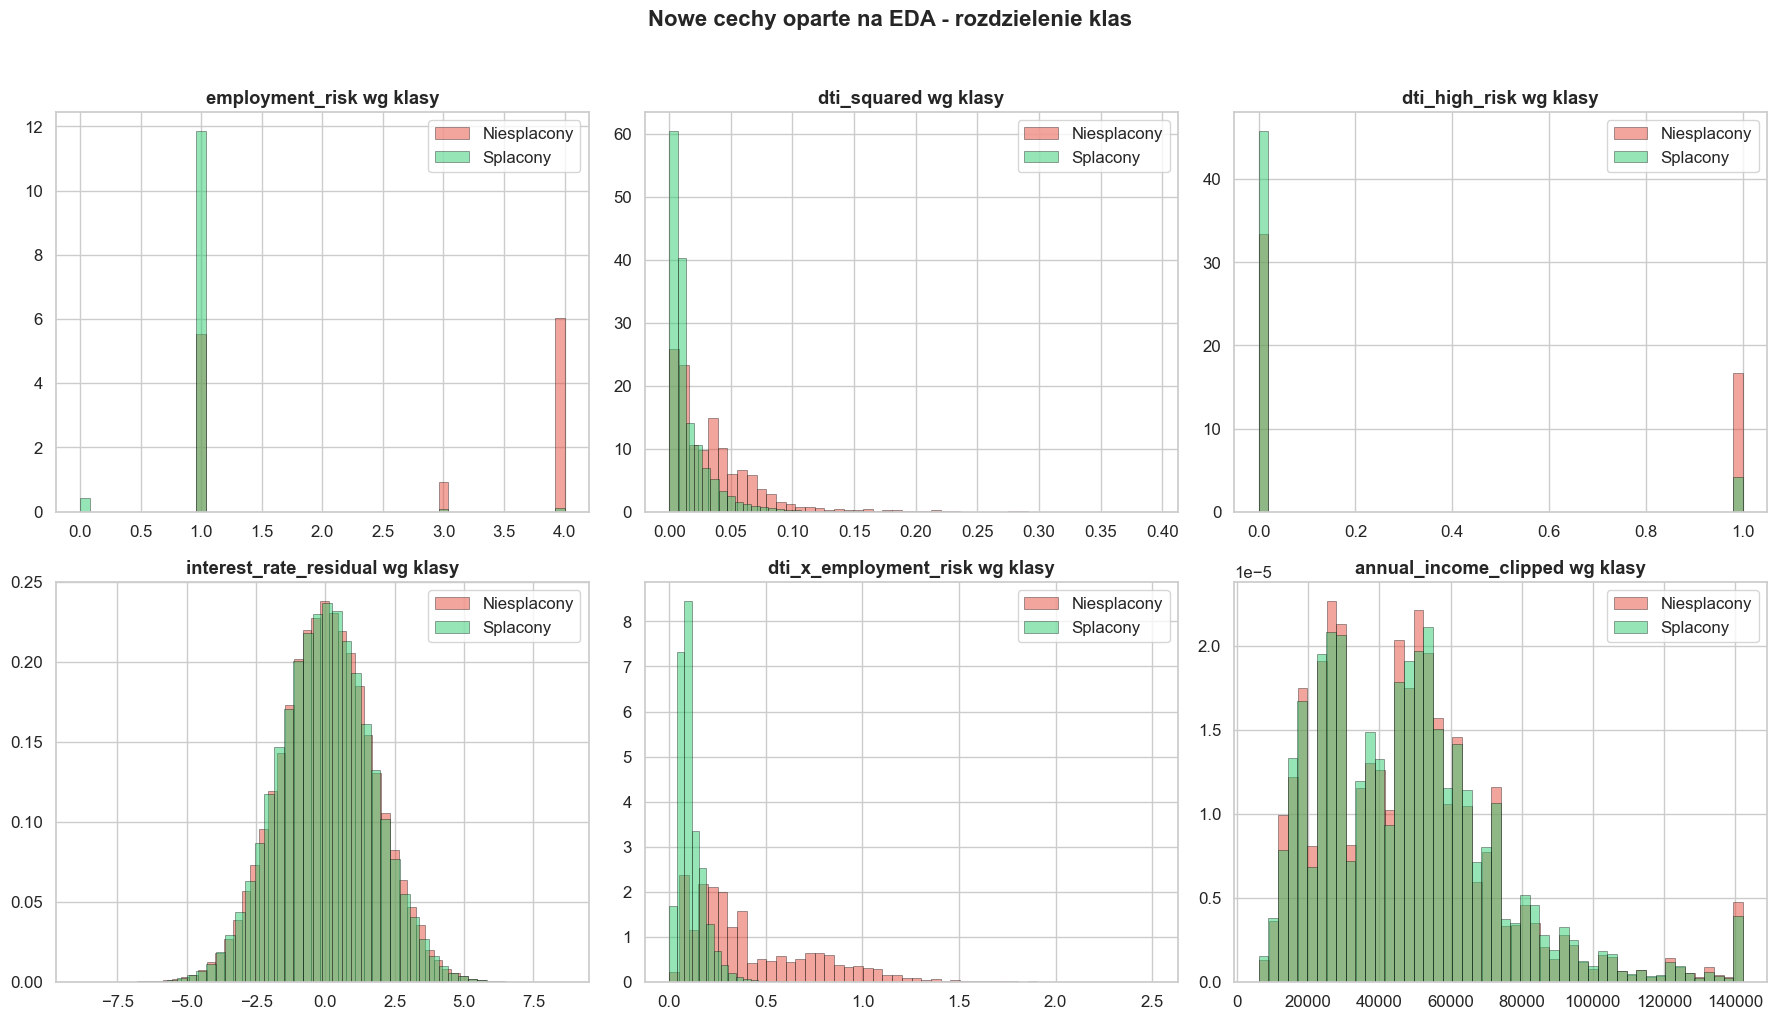

In [26]:
# Wizualizacja nowych cech opartych na eksploracji danych - czy rzeczywiscie rozdzielaja klasy?
eda_features = ['employment_risk', 'dti_squared', 'dti_high_risk', 
                'interest_rate_residual', 'dti_x_employment_risk', 'annual_income_clipped']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(eda_features):
    ax = axes[i]
    for label, color, name in [(0, '#e74c3c', 'Niesplacony'), (1, '#2ecc71', 'Splacony')]:
        subset = train[train['loan_paid_back'] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=name, density=True, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col} wg klasy', fontweight='bold')
    ax.legend()

plt.suptitle('Nowe cechy oparte na EDA - rozdzielenie klas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Wniosek:** Nowe cechy wyraznie rozdzielaja klasy:
- **employment_risk**: Niesplacone skupiaja sie przy wartosciach 3-4 (student/bezrobotny)
- **dti_squared**: Wzmacnia sygnial DTI - niesplacone przesunite w prawo
- - **dti_high_risk**: Binarna flaga - jasne rozdzielenie
- - **interest_rate_residual**: Niesplacone maja wyzsze "niewyjasnione" oprocentowanie
- - **dti_x_employment_risk**: Silna interakcja - laczy dwie najsilniejsze cechy

In [27]:
# Kodowanie cech kategorycznych za pomoca LabelEncoder
# Modele drzewiaste (LightGBM/XGBoost) moga pracowac z zakodowanymi kategoriami
cat_features = ['gender', 'marital_status', 'education_level', 
                'employment_status', 'loan_purpose', 'grade_subgrade', 'grade']

label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    # Laczmy train+test, by miec spojne kodowanie
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    label_encoders[col] = le
    print(f'  Zakodowano {col}: {len(le.classes_)} klas')

print('\nWszystkie cechy kategoryczne zakodowane')

  Zakodowano gender: 3 klas
  Zakodowano marital_status: 4 klas
  Zakodowano education_level: 5 klas
  Zakodowano employment_status: 5 klas
  Zakodowano loan_purpose: 8 klas
  Zakodowano grade_subgrade: 30 klas
  Zakodowano grade: 6 klas

Wszystkie cechy kategoryczne zakodowane


In [28]:
# Przygotowanie macierzy cech i wektora docelowego
drop_cols = ['id', 'loan_paid_back']
feature_cols = [c for c in train.columns if c not in drop_cols]

X = train[feature_cols].values
y = train['loan_paid_back'].values
X_test = test[feature_cols].values
test_ids = test['id'].values

print(f'Liczba cech: {len(feature_cols)}')
print(f'Probki treningowe: {X.shape[0]:,}')
print(f'Probki testowe: {X_test.shape[0]:,}')
print(f'\nLista cech:')
for i, f in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {f}')

Liczba cech: 45
Probki treningowe: 593,994
Probki testowe: 254,569

Lista cech:
   1. annual_income
   2. debt_to_income_ratio
   3. credit_score
   4. loan_amount
   5. interest_rate
   6. gender
   7. marital_status
   8. education_level
   9. employment_status
  10. loan_purpose
  11. grade_subgrade
  12. grade
  13. subgrade_num
  14. grade_ord
  15. grade_subgrade_ord
  16. loan_to_income
  17. debt_payment
  18. interest_x_loan
  19. monthly_payment_est
  20. payment_to_income
  21. credit_score_bucket
  22. income_bucket
  23. log_annual_income
  24. log_loan_amount
  25. credit_x_grade
  26. employment_risk
  27. is_unemployed
  28. is_student
  29. is_retired
  30. dti_squared
  31. dti_cubed
  32. dti_high_risk
  33. dti_very_high_risk
  34. log_dti
  35. annual_income_clipped
  36. income_is_outlier
  37. sqrt_income
  38. interest_rate_residual
  39. dti_x_employment_risk
  40. income_x_credit
  41. loan_x_grade
  42. dti_x_credit
  43. income_per_credit_pt
  44. dti_x_grad

In [29]:
# Nasz ostateczny dataset to trenowania
train[feature_cols]

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,...,income_is_outlier,sqrt_income,interest_rate_residual,dti_x_employment_risk,income_x_credit,loan_x_grade,dti_x_credit,income_per_credit_pt,dti_x_grade,credit_per_grade
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,...,0,171.370914,2.3884,0.084,21614840.64,7585.26,61.824,39.848019,0.252,184.000000
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,...,0,148.687659,-0.3016,0.166,14060700.72,18372.40,105.576,34.706468,0.664,127.200000
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,...,0,222.634678,-2.3364,0.097,34398942.80,51015.45,67.318,71.318273,0.291,173.500000
3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,...,0,216.467665,0.8802,0.065,24975447.25,28094.88,34.645,87.749532,0.390,76.142857
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,...,0,159.676861,-2.4490,0.053,16955305.50,48737.72,35.245,38.283333,0.212,133.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,23004.26,0.152,703,20958.37,10.92,0,2,1,0,0,...,0,151.671553,-1.0018,0.152,16171994.78,62875.11,106.856,32.676506,0.456,175.750000
593990,35289.43,0.105,559,3257.24,14.62,1,2,0,0,2,...,0,187.854811,-0.0954,0.105,19726791.37,19543.44,58.695,63.016839,0.630,79.857143
593991,47112.64,0.072,675,929.27,14.13,0,1,0,0,2,...,0,217.054463,1.6650,0.072,31801032.00,2787.81,48.600,69.693254,0.216,168.750000
593992,76748.44,0.067,740,16290.40,9.87,1,2,0,0,2,...,0,277.035088,-1.3340,0.067,56793845.60,32580.80,49.580,103.574143,0.134,246.666667


<a id='10'></a>## 10. Trening modelu (LightGBM + XGBoost)

In [30]:
N_FOLDS = 5

# Parametry LightGBM - dobrane empirycznie
lgb_params = {
    'objective': 'binary',       # Klasyfikacja binarna
    'metric': 'auc',             # Optymalizujemy AUC (zgodne z metyka konkursu)
    'boosting_type': 'gbdt',     # Klasyczny gradient boosting
    'learning_rate': 0.03,       # Niski LR = wiecej drzew, ale lepsza generalizacja
    'num_leaves': 63,            # Zlosonosc drzew - nie za duzo (overfitting)
    'max_depth': -1,             # Bez limitu glebokosci (kontrolujemy przez num_leaves)
    'min_child_samples': 50,     # Min. probek w lisciu - regularyzacja
    'feature_fraction': 0.8,     # Losowy podzbior cech na drzewo - redukcja korelacji
    'bagging_fraction': 0.8,     # Losowy podzbior danych na drzewo
    'bagging_freq': 5,           # Co 5 iteracji losujemy nowy podzbior
    'reg_alpha': 0.1,            # Regularyzacja L1
    'reg_lambda': 1.0,           # Regularyzacja L2
    'n_estimators': 3000,        # Maks. liczba drzew (early stopping zatrzyma wczesniej)
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
}

# Parametry XGBoost - podobna filozofia, inna implementacja
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.03,
    'max_depth': 6,              # XGBoost kontroluje zlozonosc glebokooscia
    'min_child_weight': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_estimators': 3000,
    'verbosity': 0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',       # Szybsza metoda budowy drzew
}

print('Modele skonfigurowane:')
print(f'  LightGBM: maks. {lgb_params["n_estimators"]} drzew, lr={lgb_params["learning_rate"]}')
print(f'  XGBoost:  maks. {xgb_params["n_estimators"]} drzew, lr={xgb_params["learning_rate"]}')
print(f'  Walidacja: {N_FOLDS}-foldowa stratyfikowana walidacja krzyzowa')

Modele skonfigurowane:
  LightGBM: maks. 3000 drzew, lr=0.03
  XGBoost:  maks. 3000 drzew, lr=0.03
  Walidacja: 5-foldowa stratyfikowana walidacja krzyzowa


In [31]:
# === TRENING LIGHTGBM ===
print("=" * 60)
print("TRENING LIGHTGBM")
print("=" * 60)

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))
lgb_fold_aucs = []
lgb_models = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'\nFold {fold}/{N_FOLDS}')
    
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)],
    )
    
    val_pred = model.predict_proba(X_val)[:, 1]
    lgb_oof[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    lgb_fold_aucs.append(fold_auc)
    lgb_models.append(model)
    print(f'  Fold {fold} AUC: {fold_auc:.6f}')
    
    # Predykcje testowe usredniamy po foldach
    lgb_test += model.predict_proba(X_test)[:, 1] / N_FOLDS

lgb_overall = roc_auc_score(y, lgb_oof)
print(f'\nLightGBM OOF AUC: {lgb_overall:.6f}')
print(f'Srednia +/- Odch.std: {np.mean(lgb_fold_aucs):.6f} +/- {np.std(lgb_fold_aucs):.6f}')

TRENING LIGHTGBM

Fold 1/5
Training until validation scores don't improve for 100 rounds
[500]	valid_0's auc: 0.922511
Early stopping, best iteration is:
[841]	valid_0's auc: 0.922999
  Fold 1 AUC: 0.922999

Fold 2/5
Training until validation scores don't improve for 100 rounds
[500]	valid_0's auc: 0.921947
Early stopping, best iteration is:
[874]	valid_0's auc: 0.922419
  Fold 2 AUC: 0.922419

Fold 3/5
Training until validation scores don't improve for 100 rounds
[500]	valid_0's auc: 0.920737
[1000]	valid_0's auc: 0.921183
Early stopping, best iteration is:
[1194]	valid_0's auc: 0.92129
  Fold 3 AUC: 0.921290

Fold 4/5
Training until validation scores don't improve for 100 rounds
[500]	valid_0's auc: 0.921536
[1000]	valid_0's auc: 0.921977
Early stopping, best iteration is:
[906]	valid_0's auc: 0.922015
  Fold 4 AUC: 0.922015

Fold 5/5
Training until validation scores don't improve for 100 rounds
[500]	valid_0's auc: 0.921301
Early stopping, best iteration is:
[649]	valid_0's auc: 0.9

In [32]:
# === TRENING XGBOOST ===
print("=" * 60)
print("TRENING XGBOOST")  
print("=" * 60)

xgb_oof = np.zeros(len(X))
xgb_test = np.zeros(len(X_test))
xgb_fold_aucs = []
xgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'\nFold {fold}/{N_FOLDS}')
    
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    val_pred = model.predict_proba(X_val)[:, 1]
    xgb_oof[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    xgb_fold_aucs.append(fold_auc)
    xgb_models.append(model)
    print(f'  Fold {fold} AUC: {fold_auc:.6f}')
    
    xgb_test += model.predict_proba(X_test)[:, 1] / N_FOLDS

xgb_overall = roc_auc_score(y, xgb_oof)
print(f'\nXGBoost OOF AUC: {xgb_overall:.6f}')
print(f'Srednia +/- Odch.std: {np.mean(xgb_fold_aucs):.6f} +/- {np.std(xgb_fold_aucs):.6f}')

TRENING XGBOOST

Fold 1/5
  Fold 1 AUC: 0.923381

Fold 2/5
  Fold 2 AUC: 0.922769

Fold 3/5
  Fold 3 AUC: 0.921259

Fold 4/5
  Fold 4 AUC: 0.922064

Fold 5/5
  Fold 5 AUC: 0.921730

XGBoost OOF AUC: 0.922236
Srednia +/- Odch.std: 0.922240 +/- 0.000753


In [ ]:
# === ENSEMBLE - szukamy optymalnej wagi mieszania ===
# Idea: rozne modele popelniaja rozne bledy.
# Usrednianie predykcji redukuje wariancje i czesto podnosi AUC.
print("=" * 60)
print("MIESZANIE MODELI (ENSEMBLE)")
print("=" * 60)

best_auc = 0
best_w = 0

for w in np.arange(0.0, 1.01, 0.05):    # [0.05, 0.1, 0.15, 1.0]
    blended = w * lgb_oof + (1 - w) * xgb_oof
    auc = roc_auc_score(y, blended)
    if auc > best_auc:
        best_auc = auc
        best_w = w
    print(f'  LGB={w:.2f}, XGB={1-w:.2f} -> AUC={auc:.6f}')

print(f'\nNajlepszy ensemble: LGB={best_w:.2f}, XGB={1-best_w:.2f} -> AUC={best_auc:.6f}')
print(f'  Sam LightGBM: {lgb_overall:.6f}')
print(f'  Sam XGBoost:  {xgb_overall:.6f}')
print(f'  Zysk z ensemble: +{best_auc - max(lgb_overall, xgb_overall):.6f}')

# Finalne predykcje z optymalnym mieszaniem
oof_preds = best_w * lgb_oof + (1 - best_w) * xgb_oof
test_preds = best_w * lgb_test + (1 - best_w) * xgb_test

MIESZANIE MODELI (ENSEMBLE)
  LGB=0.00, XGB=1.00 -> AUC=0.922236
  LGB=0.05, XGB=0.95 -> AUC=0.922324
  LGB=0.10, XGB=0.90 -> AUC=0.922400
  LGB=0.15, XGB=0.85 -> AUC=0.922465
  LGB=0.20, XGB=0.80 -> AUC=0.922519
  LGB=0.25, XGB=0.75 -> AUC=0.922564
  LGB=0.30, XGB=0.70 -> AUC=0.922598
  LGB=0.35, XGB=0.65 -> AUC=0.922622
  LGB=0.40, XGB=0.60 -> AUC=0.922637
  LGB=0.45, XGB=0.55 -> AUC=0.922641
  LGB=0.50, XGB=0.50 -> AUC=0.922636
  LGB=0.55, XGB=0.45 -> AUC=0.922621
  LGB=0.60, XGB=0.40 -> AUC=0.922596
  LGB=0.65, XGB=0.35 -> AUC=0.922561
  LGB=0.70, XGB=0.30 -> AUC=0.922516
  LGB=0.75, XGB=0.25 -> AUC=0.922461
  LGB=0.80, XGB=0.20 -> AUC=0.922396
  LGB=0.85, XGB=0.15 -> AUC=0.922320
  LGB=0.90, XGB=0.10 -> AUC=0.922233
  LGB=0.95, XGB=0.05 -> AUC=0.922135
  LGB=1.00, XGB=0.00 -> AUC=0.922026

Najlepszy ensemble: LGB=0.45, XGB=0.55 -> AUC=0.922641
  Sam LightGBM: 0.922026
  Sam XGBoost:  0.922236
  Zysk z ensemble: +0.000405


**Wniosek z treningu:**- Oba modele osiagaja bardzo zblizone AUC (~0.922)

<a id='11'></a>## 11. Waznosc cech i interpretacja modelu
Sprawdzamy, ktore cechy model uznal za najwazniejsze, by 
1. Walidowac nasze decyzje z EDA
2. Potencjalnie usunac bezuzyteczne cechy
3. Zrozumiec, co napedza predykcje

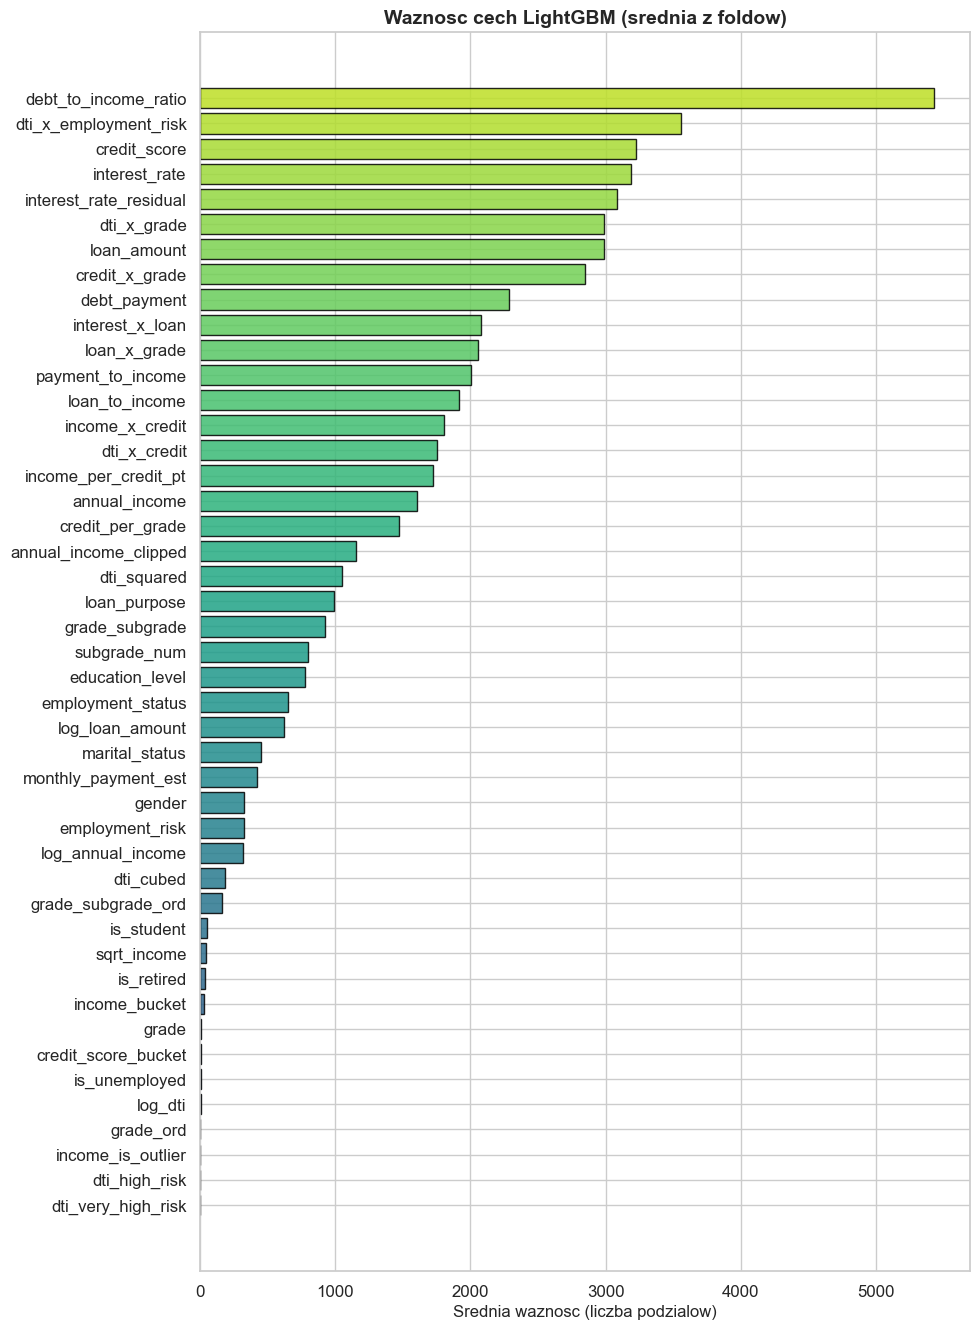


Top 15 najwazniejszych cech:
                 cecha  waznosc
  debt_to_income_ratio   5426.2
 dti_x_employment_risk   3560.4
          credit_score   3221.6
         interest_rate   3186.2
interest_rate_residual   3084.6
           dti_x_grade   2990.4
           loan_amount   2989.2
        credit_x_grade   2845.0
          debt_payment   2285.8
       interest_x_loan   2078.8
          loan_x_grade   2055.8
     payment_to_income   2002.0
        loan_to_income   1916.6
       income_x_credit   1803.8
          dti_x_credit   1750.6


In [34]:
# Waznosc cech LightGBM (usredniona po foldach)
importances = np.zeros(len(feature_cols))
for m in lgb_models:
    importances += m.feature_importances_ / N_FOLDS

feat_imp = pd.DataFrame({'cecha': feature_cols, 'waznosc': importances})
feat_imp = feat_imp.sort_values('waznosc', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(feature_cols) * 0.3)))
colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp)))
ax.barh(feat_imp['cecha'], feat_imp['waznosc'], color=colors_imp, edgecolor='black', alpha=0.85)
ax.set_xlabel('Srednia waznosc (liczba podzialow)', fontsize=12)
ax.set_title('Waznosc cech LightGBM (srednia z foldow)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 15 najwazniejszych cech:')
print(feat_imp.sort_values('waznosc', ascending=False).head(15).to_string(index=False))

**Wnioski z waznosci cech:**
- **debt_to_income_ratio** jest zdecydowanie najwazniejsza cecha
- Cechy interakcyjne (credit_x_grade, interest_x_loan, debt_payment) sa wysoko - nasze inzynieria cech dziala.
- - **employment_risk** i flagi (is_unemployed) pojawiaja sie w czolowce - potwierdzenie odkrycia z sekcji 6.
- - **gender** i **marital_status** maja niska waznosc - co pasuje do obserwacji ze slabo rozdzielaja klasy.

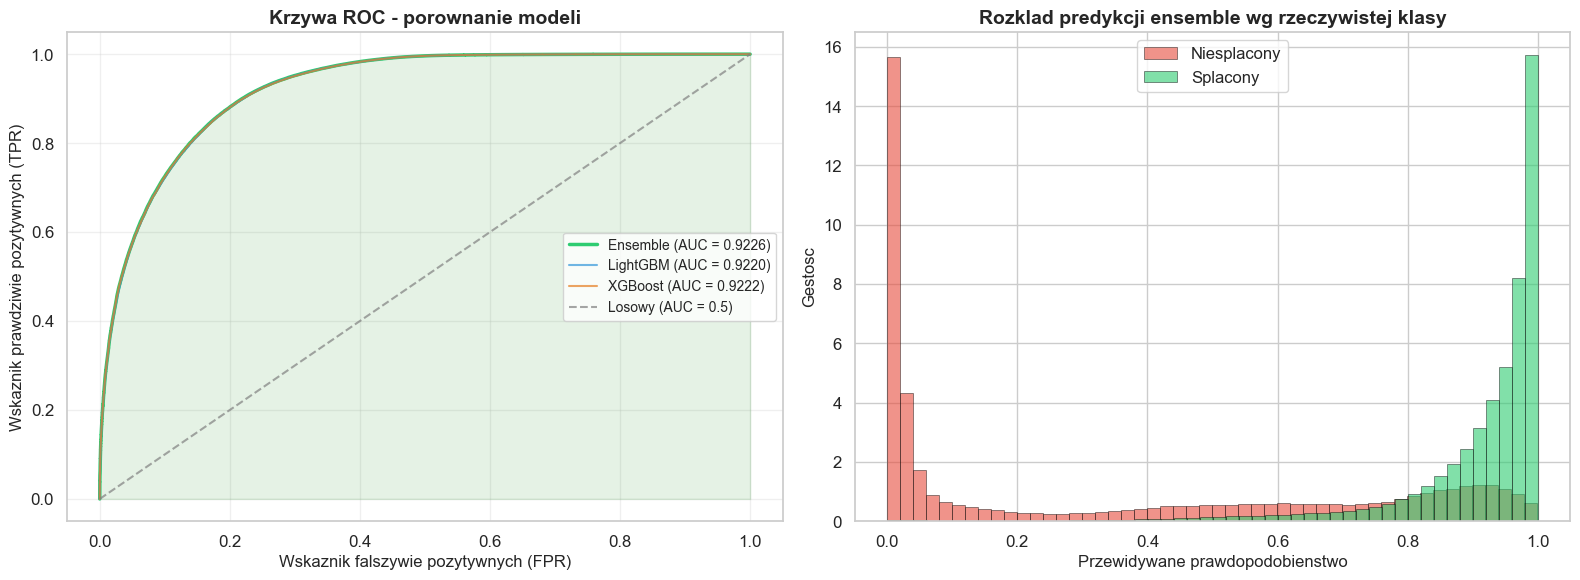

In [35]:
# Krzywa ROC - porownanie modeli
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fpr, tpr, thresholds = roc_curve(y, oof_preds)
fpr_lgb, tpr_lgb, _ = roc_curve(y, lgb_oof)
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb_oof)

axes[0].plot(fpr, tpr, color='#2ecc71', linewidth=2.5, label=f'Ensemble (AUC = {best_auc:.4f})')
axes[0].plot(fpr_lgb, tpr_lgb, color='#3498db', linewidth=1.5, alpha=0.7, label=f'LightGBM (AUC = {lgb_overall:.4f})')
axes[0].plot(fpr_xgb, tpr_xgb, color='#e67e22', linewidth=1.5, alpha=0.7, label=f'XGBoost (AUC = {xgb_overall:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7, label='Losowy (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='green')
axes[0].set_xlabel('Wskaznik falszywie pozytywnych (FPR)', fontsize=12)
axes[0].set_ylabel('Wskaznik prawdziwie pozytywnych (TPR)', fontsize=12)
axes[0].set_title('Krzywa ROC - porownanie modeli', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Rozklad predykcji
axes[1].hist(oof_preds[y == 0], bins=50, alpha=0.6, color='#e74c3c', label='Niesplacony', density=True, edgecolor='black', linewidth=0.5)
axes[1].hist(oof_preds[y == 1], bins=50, alpha=0.6, color='#2ecc71', label='Splacony', density=True, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Przewidywane prawdopodobienstwo', fontsize=12)
axes[1].set_ylabel('Gestosc', fontsize=12)
axes[1].set_title('Rozklad predykcji ensemble wg rzeczywistej klasy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

**Wnioski z krzywych ROC:**- Wszystkie trzy modele sa bardzo blisko siebie, co potwierdza stabilnosc.- Krzywa ROC jest daleko od przekatnej (losowy model) - model ma silna moc dyskryminacyjna.- Rozklad predykcji pokazuje dobra separacje: niesplacone skupiaja sie blisko 0, splacone blisko 1. Jednak nie ma idealnego rozdzialu - co jest normalne dla tego typu danych.

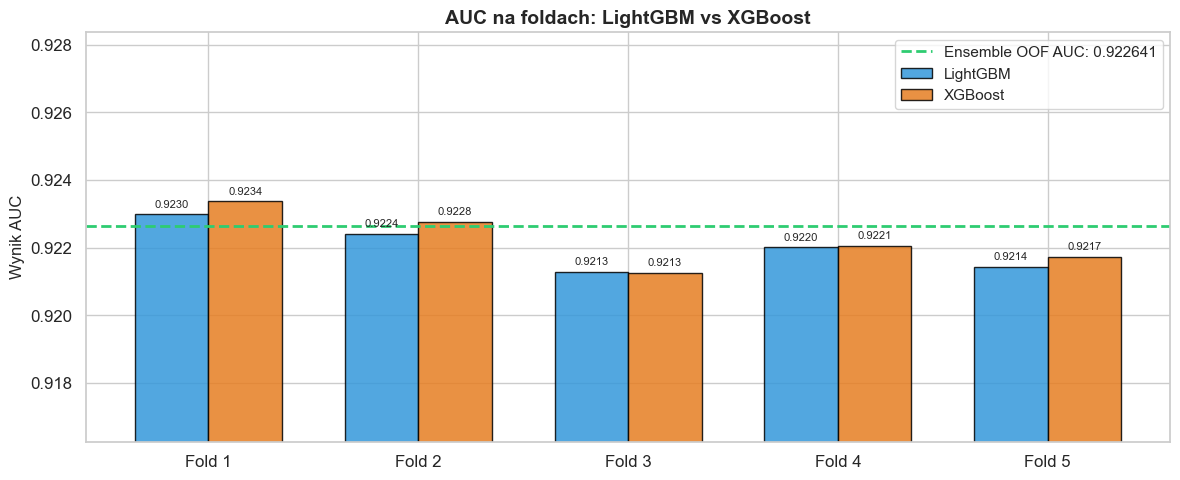

In [36]:
# Porownanie AUC po foldach
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(N_FOLDS)
width = 0.35

bars1 = ax.bar(x - width/2, lgb_fold_aucs, width, label='LightGBM', color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_fold_aucs, width, label='XGBoost', color='#e67e22', edgecolor='black', alpha=0.85)

ax.axhline(y=best_auc, color='#2ecc71', linestyle='--', linewidth=2, label=f'Ensemble OOF AUC: {best_auc:.6f}')
ax.set_ylabel('Wynik AUC', fontsize=12)
ax.set_title('AUC na foldach: LightGBM vs XGBoost', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.legend(fontsize=11)

for bar, auc in zip(bars1, lgb_fold_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002, f'{auc:.4f}', ha='center', fontsize=8)
for bar, auc in zip(bars2, xgb_fold_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002, f'{auc:.4f}', ha='center', fontsize=8)

ax.set_ylim(min(min(lgb_fold_aucs), min(xgb_fold_aucs)) - 0.005, max(max(lgb_fold_aucs), max(xgb_fold_aucs)) + 0.005)
plt.tight_layout()
plt.show()

Optymalny prog decyzyjny (statystyka J Youdena): 0.7904


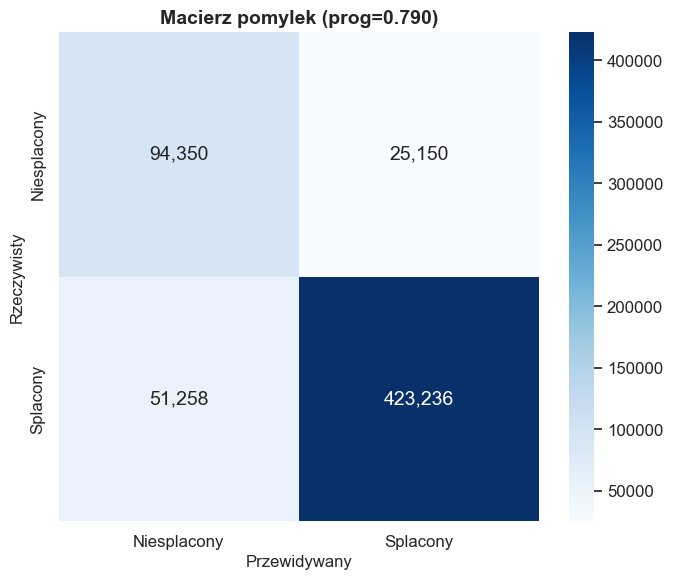


Raport klasyfikacji (prog=0.790):
              precision    recall  f1-score   support

 Niesplacony       0.65      0.79      0.71    119500
    Splacony       0.94      0.89      0.92    474494

    accuracy                           0.87    593994
   macro avg       0.80      0.84      0.81    593994
weighted avg       0.88      0.87      0.88    593994



In [37]:
# Macierz pomylek przy optymalnym progu
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optymalny prog decyzyjny (statystyka J Youdena): {optimal_threshold:.4f}")

y_pred_optimal = (oof_preds >= optimal_threshold).astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax, 
            xticklabels=['Niesplacony', 'Splacony'], yticklabels=['Niesplacony', 'Splacony'],
            annot_kws={'size': 14})
ax.set_xlabel('Przewidywany', fontsize=12)
ax.set_ylabel('Rzeczywisty', fontsize=12)
ax.set_title(f'Macierz pomylek (prog={optimal_threshold:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nRaport klasyfikacji (prog={optimal_threshold:.3f}):')
print(classification_report(y, y_pred_optimal, target_names=['Niesplacony', 'Splacony']))

**Wniosek z macierzy pomylek:** Model dobrze identyfikuje oba typy - zarowno splacone, jak i niesplacone kredyty. Recall (czulosc) dla klasy "Niesplacony" jest kluczowy z perspektywy banku 

<a id='12'></a>## 12. Submission

In [38]:
submission = pd.DataFrame({'id': test_ids, 'loan_paid_back': test_preds})
submission.to_csv('submission.csv', index=False)
